# Notebook 01 — Baseline Chen2020 C/3 Smoke Test

## Goal

This notebook verifies that the `pybamm-aging-bridge` environment can run a baseline Chen2020 DFN simulation under a standard C/3 discharge–rest–charge–CV protocol.

This is an infrastructure and baseline sanity test only. No aging perturbation is applied in this notebook.

## Scientific context

The project aims to build a mechanism-to-observable bridge for lithium-ion battery aging diagnostics:

DFN-level physical perturbation  
→ simulated cell response  
→ HPPC / charge-discharge evaluation  
→ ECM-level observable extraction  
→ aging diagnostic fingerprint

This first notebook only confirms that the baseline model, parameter set, solver workflow, data export, and plotting pipeline are functional.

## Workflow

1. Import required packages and audit software versions.
2. Define project paths for data and figures.
3. Load the Chen2020 parameter set.
4. Build a DFN model.
5. Run a baseline C/3 protocol:
   - Discharge at C/3 until 2.5 V
   - Rest for 30 min
   - Charge at C/3 until 4.2 V
   - Hold at 4.2 V until C/100
6. Export voltage, current, and time data.
7. Plot voltage and current profiles.
8. Perform basic sanity checks on voltage, current, and simulation duration.

## Expected outputs

- `data/baseline_chen2020_c3_charge_discharge.csv`
- `figures/baseline_chen2020_c3_voltage.png`
- `figures/baseline_chen2020_c3_current.png`

## Interpretation boundary

This notebook does not evaluate aging, degradation, SOH, Ri, tau1/tau2, or diagnostic fingerprints.

A successful run only means that the baseline PyBaMM simulation chain is operational. The next notebook will introduce a one-SOC HPPC smoke test to verify Ri extraction and relaxation availability.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pybamm

print("PyBaMM version:", pybamm.__version__)

ROOT = Path.cwd()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"
FIGURES = ROOT / "figures"

DATA.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)

print("ROOT:", ROOT)
print("DATA:", DATA)
print("FIGURES:", FIGURES)

PyBaMM version: 26.3.1
ROOT: /Users/louislu/projects/pybamm-aging-bridge
DATA: /Users/louislu/projects/pybamm-aging-bridge/data
FIGURES: /Users/louislu/projects/pybamm-aging-bridge/figures


In [2]:
model = pybamm.lithium_ion.DFN()

param = pybamm.ParameterValues("Chen2020")

experiment = pybamm.Experiment(
    [
        "Discharge at C/3 until 2.5 V",
        "Rest for 30 minutes",
        "Charge at C/3 until 4.2 V",
        "Hold at 4.2 V until C/100",
    ],
    period="10 seconds",
)

print("Model:", type(model).__name__)
print("Parameter set: Chen2020")

print("\nExperiment steps:")
for i, step in enumerate(experiment.steps):
    print(f"{i+1}.", step)

Model: DFN
Parameter set: Chen2020

Experiment steps:
1. Discharge at C/3 until 2.5 V
2. Rest for 30 minutes
3. Charge at C/3 until 4.2 V
4. Hold at 4.2 V until C/100


In [3]:
sim = pybamm.Simulation(
    model,
    parameter_values=param,
    experiment=experiment,
)

solution = sim.solve()

print("[OK] simulation solved")
print("Termination:", solution.termination)

[OK] simulation solved
Termination: event: C-rate cut-off [experiment]


In [4]:
df = pd.DataFrame(
    {
        "time_s": solution["Time [s]"].entries,
        "time_min": solution["Time [s]"].entries / 60,
        "voltage_V": solution["Terminal voltage [V]"].entries,
        "current_A_pybamm": solution["Current [A]"].entries,
    }
)

out_csv = DATA / "baseline_chen2020_c3_charge_discharge.csv"
df.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
print("\nHead:")
display(df.head())

print("\nTail:")
display(df.tail())

print("\nDescribe:")
display(df.describe())

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/baseline_chen2020_c3_charge_discharge.csv

Head:


,time_s,time_min,voltage_V,current_A_pybamm
0,0.0,0.000000,4.114430,1.666667
1,10.0,0.166667,4.100616,1.666667
2,20.0,0.333333,4.091986,1.666667
3,30.0,0.500000,4.085637,1.666667
4,40.0,0.666667,4.080583,1.666667



Tail:


,time_s,time_min,voltage_V,current_A_pybamm
2642,26383.247246,439.720787,4.2,-0.051518
2643,26393.247246,439.887454,4.2,-0.051060
2644,26403.247246,440.054121,4.2,-0.050606
2645,26413.247246,440.220787,4.2,-0.050157
2646,26416.767109,440.279452,4.2,-0.050000



Describe:


,time_s,time_min,voltage_V,current_A_pybamm
count,2647.000000,2647.000000,2647.000000,2647.000000
mean,13216.163627,220.269394,3.711998,-0.005798
std,7630.461250,127.174354,0.418694,1.498946
min,0.000000,0.000000,2.500000,-1.666688
25%,6615.000000,110.250000,3.513051,-1.666667
50%,13209.100865,220.151681,3.775641,-0.079162
75%,19824.100865,330.401681,4.032624,1.666667
max,26416.767109,440.279452,4.200000,1.666667


PyBaMM convention: +I = discharge, -I = charge
Experimental convention used in this project: +I_exp = charge, -I_exp = discharge



{'pybamm_current_max_A': np.float64(1.6666666666666665),
 'pybamm_current_min_A': np.float64(-1.66668795011652),
 'exp_current_max_A': np.float64(1.66668795011652),
 'exp_current_min_A': np.float64(-1.6666666666666665)}

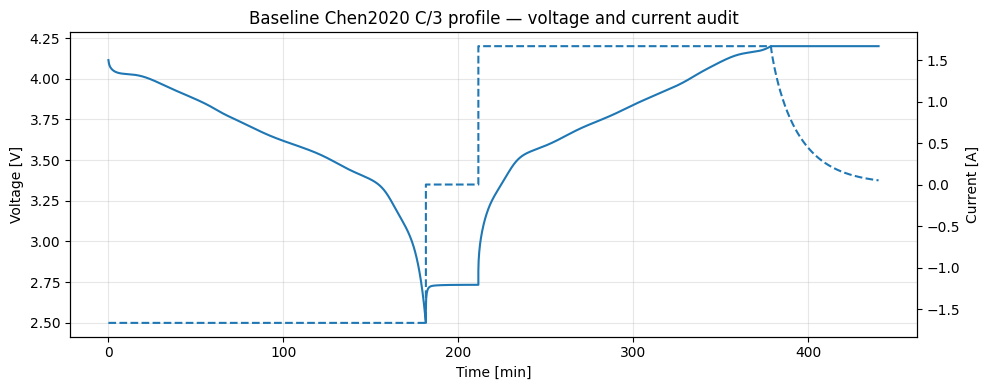

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/baseline_chen2020_c3_voltage_current_audit.png


In [5]:
df["current_A_exp"] = -df["current_A_pybamm"]

print("PyBaMM convention: +I = discharge, -I = charge")
print("Experimental convention used in this project: +I_exp = charge, -I_exp = discharge")
print()

sign_audit = {
    "pybamm_current_max_A": df["current_A_pybamm"].max(),
    "pybamm_current_min_A": df["current_A_pybamm"].min(),
    "exp_current_max_A": df["current_A_exp"].max(),
    "exp_current_min_A": df["current_A_exp"].min(),
}
display(sign_audit)

fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(df["time_min"], df["voltage_V"], label="Terminal voltage [V]")
ax1.set_xlabel("Time [min]")
ax1.set_ylabel("Voltage [V]")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(df["time_min"], df["current_A_exp"], linestyle="--", label="Current [A], exp convention")
ax2.set_ylabel("Current [A]")

plt.title("Baseline Chen2020 C/3 profile — voltage and current audit")

fig.tight_layout()
fig_path = FIGURES / "baseline_chen2020_c3_voltage_current_audit.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)